# HST astroquery use case: Searching for white dwarfs in the Globular Cluster M4

This use case is based on the MAST use case [here](https://archive.stsci.edu/hst/hsc/help/use_case_5_v2.html). 

The science case is searching for white dwarfs (i.e. in the Globular Cluster M4; [Richer et al. 1997, ApJ 484, 741](http://adsabs.harvard.edu/abs/1997ApJ...484..741R)). 

Workflow:
1. Query the Hubble Source Catalog (HSC) for sources in the Globular Cluster M4 that have both WFC3 F275W and F814W magnitudes, filter to find only stars and reject poor measurements. 
2. Search for observations of M4 in the HST archive. 
3. Download and visualise an image.
4. Plot the HSC sources on the image. 
5. Create a colour-magnitude diagram to help identify white dwarfs. 
6. Select the white dwarf candidates and plot these on the image.

In [1]:
# Import ESAHubble from astroquery.esa.hubble
from astroquery.esa.hubble import ESAHubble
esahubble = ESAHubble()

Created TAP+ (v20200428.1) - Connection:
	Host: hst.esac.esa.int
	Use HTTPS: False
	Port: 80
	SSL Port: 443
Created TAP+ (v20200428.1) - Connection:
	Host: hst.esac.esa.int
	Use HTTPS: False
	Port: 80
	SSL Port: 443


### Step 1. Query the HSC

The following performs an Astronomical Data Query Language (ADQL) query to the Hubble Source Catalog (HSC) for sources in the Globular Cluster M4 in radius 500 arcseconds, that have both WFC3 F275W and F814W magnitudes, filter to find only stars (low CI number) and low magnitude errors.

The WHERE clause defines the search parameters:
* concentration index (CI) is less than 1.25 (to find only stars)
* number of images in a match (>2)
* W3_F275W and W3_F814W must be greater than 0 (to ignore objects with only one color)
* W3_F275W_Sigma and W3_F814W_Sigma must be less than 1.0 (to ignore objects with poor measurements)

See [here](https://gea.esac.esa.int/archive-help/adql/examples/index.html) for more information and examples of ADQL queries. 

In [2]:
hsc = esahubble.query_hst_tap("SELECT match_ra, match_dec, match_id, num_images, w3_f275w, w3_f814w, w3_f275w - w3_f814w \
FROM hsc_v2.hubble_sc2 \
WHERE 1=CONTAINS( \
  POINT('ICRS', match_ra, match_dec), \
  CIRCLE('ICRS', 245.89675, -26.52575, 0.138889)) \
AND ci < 1.25 \
AND num_images > 2 \
AND (w3_f275w > 0 and w3_f814w > 0) \
AND w3_f275w_sigma < 1.0 \
AND w3_f814w_sigma < 1.0 \
ORDER BY match_id ASC", "M4.vot")
print(hsc)

# Brings back a table of ~381 rows. 

INFO: Query finished. [astroquery.utils.tap.core]
     match_ra           match_dec      ...      w3_f814w            expr1       
------------------ ------------------- ... ------------------ ------------------
245.89302954800334 -26.511680560089676 ... 15.553799629211426  5.887249946594238
 245.8972766368185  -26.51379074271159 ... 15.504600048065186  7.847449779510498
 245.8990812664547 -26.513830608407527 ... 22.485200881958008 1.3590984344482422
245.90316023702925 -26.509754587044668 ... 17.698999404907227  4.973400115966797
245.90739563406606 -26.507770827794975 ...  19.34249973297119 4.4902496337890625
245.91624557213004 -26.488874377989244 ... 17.845300674438477    5.1260986328125
 245.9086893765596 -26.513608251443415 ... 18.405250549316406  4.773499488830566
 245.9132813103605 -26.491321239947954 ... 16.106199264526367  4.327800750732422
245.91129428025005 -26.506855010540566 ... 17.576400756835938  5.688999176025391
 245.9178763468632 -26.490524485760822 ...  16.999200820922

### Step 2. Search for observations of M4 in the HST archive.

The following will perform a cone search on M4 (coordinates = 245.89675 -26.52575) with a radius of 3 arcminutes. The result of the query will be stored in the votable file 'cone_search_m4_3.vot':

In [3]:
from astropy import coordinates
c = coordinates.SkyCoord(245.89675, -26.52575, unit="deg", frame='icrs')
cone = esahubble.cone_search(c, 3, "cone_search_m4_3.vot")
cone

OBSERVATION_ID,START_TIME,END_TIME,START_TIME_MJD,END_TIME_MJD,EXPOSURE_DURATION,RELEASE_DATE,RUN_ID,PROGRAM_ID,SET_ID,COLLECTION,INTENT,MEMBERS_NO,INSTRUMENT_CONFIGURATION,TYPE,MOVING_TARGET,TARGET_NAME,TARGET_DESCRIPTION,PROPOSAL_ID,PI_NAME,PROPOSAL_TITLE,INSTRUMENT_NAME,METADATA_PROVENANCE,DATA_PRODUCT_TYPE,SOFTWARE_VERSION,RA,DEC,GAL_LAT,GAL_LON,ECL_LAT,ECL_LON,FOV_SIZE,WAVE_CENTRAL,WAVE_BANDWIDTH,WAVE_MAX,WAVE_MIN,FILTER
,iso-8601,iso-8601,,,,iso-8601,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
object,object,object,float64,float64,float64,object,object,object,object,object,object,int32,object,object,bool,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object
j8fe01010,2002-07-14 04:42:23.74,2002-07-14 06:28:33.78,52469.11277476852,52469.186502083336,1440.0,2002-07-14 15:10:36.0,01,8fe,01,HST,science,4,APERTURE=WFC|DETECTOR=WFC|EXPEND=52469.186502083336|EXPSTART=52469.11277476852|EXPTIME=1440.0|FILTER=F775W;CLEAR2L|OBSMODE=ACCUM|OBSTYPE=IMAGING,HST Composite,False,NGC6121-CALIB,BROAD_CATEGORY=CALIBRATION;STELLAR CLUSTER|TARGET_DESCRIP=CALIBRATION;POINT SPREAD FUNCTION;;STELLAR CLUSTER;GLOBULAR CLUSTER,9578,"Rhodes, Jason D.",Cosmic Shear With ACS Pure Parallels. Targeted Portion.,ACS/WFC,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",image,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",245.91509927039274,-26.511944807804138,--,--,--,--,0.09686500395130701,650.0,900.0000000000001,1100.0,200.0,F775W;CLEAR2L
j8fe01rjq,2002-07-14 06:31:46.747,2002-07-14 06:37:47.797,52469.188735497686,52469.19291431713,360.0,2002-07-14 15:14:42.0,rj,8fe,01,HST,science,0,APERTURE=JWFC|ASNID=NONE|DETECTOR=WFC|EXPEND=52469.19291431713|EXPSTART=52469.188735497686|EXPTIME=360.0|FILTER=F775W;CLEAR2L|OBSMODE=ACCUM|OBSTYPE=IMAGING,HST Singleton,False,NGC6121-CALIB,BROAD_CATEGORY=CALIBRATION;STELLAR CLUSTER|TARGET_DESCRIP=CALIBRATION;POINT SPREAD FUNCTION;;STELLAR CLUSTER;GLOBULAR CLUSTER,9578,"Rhodes, Jason D.",Cosmic Shear With ACS Pure Parallels. Targeted Portion.,ACS/WFC,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",image,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",245.91509423130802,-26.51193575420048,--,--,--,--,0.08297739536729412,650.0,900.0000000000001,1100.0,200.0,F775W;CLEAR2L
j8fe02010,2003-01-19 20:20:31.987,2003-01-19 20:52:09.033,52658.805925775465,52658.82788232639,1440.0,2003-01-20 16:49:40.0,01,8fe,02,HST,science,4,APERTURE=WFC|DETECTOR=WFC|EXPEND=52658.82788232639|EXPSTART=52658.805925775465|EXPTIME=1440.0|FILTER=F775W;CLEAR2L|OBSMODE=ACCUM|OBSTYPE=IMAGING,HST Composite,False,NGC6121-CALIB,BROAD_CATEGORY=CALIBRATION;STELLAR CLUSTER|TARGET_DESCRIP=CALIBRATION;POINT SPREAD FUNCTION;;STELLAR CLUSTER;GLOBULAR CLUSTER,9578,"Rhodes, Jason D.",Cosmic Shear With ACS Pure Parallels. Targeted Portion.,ACS/WFC,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",image,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",245.9226371812945,-26.513059323931415,--,--,--,--,0.09686412637242661,650.0,900.0000000000001,1100.0,200.0,F775W;CLEAR2L
j8fe02b8q,2003-01-19 20:55:02.003,2003-01-19 21:01:03.05,52658.829884293984,52658.834063078706,360.0,2003-01-20 17:01:18.0,b8,8fe,02,HST,science,0,APERTURE=JWFC|ASNID=NONE|DETECTOR=WFC|EXPEND=52658.834063078706|EXPSTART=52658.829884293984|EXPTIME=360.0|FILTER=F775W;CLEAR2L|OBSMODE=ACCUM|OBSTYPE=IMAGING,HST Singleton,False,NGC6121-CALIB,BROAD_CATEGORY=CALIBRATION;STELLAR CLUSTER|TARGET_DESCRIP=CALIBRATION;POINT SPREAD FUNCTION;;STELLAR CLUSTER;GLOBULAR CLUSTER,9578,"Rhodes, Jason D.",Cosmic Shear With ACS Pure Parallels. Targeted Portion.,ACS/WFC,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5",image,"CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e2

The following performs a query to find all HST WFC3 images in filter F814W and with intent = SCIENCE:

In [4]:
criteria = esahubble.query_criteria(calibration_level = 3, \
                                    data_product_type = 'image', \
                                    intent='SCIENCE', \
                                    obs_collection=['HST'], \
                                    instrument_name = ['WFC3'], \
                                    filters = ['F814W'], \
                                    async_job = True, \
                                    output_file = 'output1.vot.gz', \
                                    output_format="votable", \
                                    verbose = True, \
                                    get_query = False)
criteria

Saving results to: output1.vot.gz
INFO: select o.*, p.calibration_level, p.data_product_type from ehst.observation AS o LEFT JOIN ehst.plane as p on o.observation_uuid=p.observation_uuid where(p.calibration_level LIKE '%PRODUCT%' AND p.data_product_type LIKE '%image%' AND o.intent LIKE '%SCIENCE%' AND (o.collection LIKE '%HST%') AND (o.instrument_name LIKE '%WFC3%') AND (o.instrument_configuration LIKE '%F814W%')) [astroquery.esa.hubble.core]


algorithm_name,collection,end_time,end_time_mjd,exposure_duration,instrument_configuration,instrument_name,intent,members,members_number,observation_id,observation_uuid,obs_type,obs_type_hibernate,pi_name,program_id,proposal_id,release_date,run_id,set_id,start_time,start_time_mjd,target_description,target_moving,target_name,calibration_level,data_product_type
object,object,str1,float64,float64,object,object,object,object,int64,object,object,object,str1,object,object,object,str1,object,object,str1,float64,object,bool,object,object,object
exposure,HST,2,57233.44772280093,165.0,APERTURE=IUVIS|ASNID=NONE|DETECTOR=UVIS|EXPEND=57233.44772280093|EXPSTART=57233.44581304398|EXPTIME=165.0|FILTER=F814W|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,,0,icp011teq,00000000-0000-0000-b821-31e4781266e6,HST Singleton,S,"Koch, Andreas",cp0,13758,2,te,11,2,57233.44581304398,BROAD_CATEGORY=STAR|TARGET_DESCRIP=STAR;BULGE,False,BULGE-SWEEPS,PRODUCT,image
multidrizzle,HST,2,57289.15156678,5700.0,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=57289.15156678|EXPSTART=57289.05385847|EXPTIME=5700.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/hst_13701_08_wfc3_uvis_f814w_ick808qh caom:HST/hst_13701_08_wfc3_uvis_f814w_ick808qj caom:HST/hst_13701_08_wfc3_uvis_f814w_ick808qm caom:HST/hst_13701_08_wfc3_uvis_f814w_ick808qq,4,hst_13701_08_wfc3_uvis_f814w_ick808,00000000-0000-0000-b9be-3f46afb18208,HAP Composite,C,"Mihos, Chris",st_,13701,2,70,13,2,57289.05385847,,False,M101-NE-PLUME,PRODUCT,image
multidrizzle,HST,2,57119.79268522,1316.0,APERTURE=UVIS|DETECTOR=UVIS|EXPEND=57119.79268522|EXPSTART=57119.77594914|EXPTIME=1316.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/hst_13682_06_wfc3_uvis_f814w_icjr06kh caom:HST/hst_13682_06_wfc3_uvis_f814w_icjr06kk,2,hst_13682_06_wfc3_uvis_f814w_icjr06,00000000-0000-0000-80ad-a66080a9016a,HAP Composite,C,"van Dokkum, Pieter",st_,13682,2,68,13,2,57119.77594914,,False,ANY,PRODUCT,image
multidrizzle,HST,2,57036.69247503,300.0,APERTURE=UVIS1|DETECTOR=UVIS|EXPEND=57036.69247503|EXPSTART=57036.68900264|EXPTIME=300.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/hst_13643_04_wfc3_uvis_f814w_icjg04p7,1,hst_13643_04_wfc3_uvis_f814w_icjg04,00000000-0000-0000-9324-7c501bbbcd8a,HAP Composite,C,"Duchene, Gaspard",st_,13643,2,64,13,2,57036.68900264,,False,SSTGBSJ111110.7-764157,PRODUCT,image
multidrizzle,HST,2,57165.85842741,1100.0,APERTURE=UVIS|DETECTOR=UVIS|EXPEND=57165.85842741|EXPSTART=57165.84569614|EXPTIME=1100.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/hst_13787_02_wfc3_uvis_f814w_ickj02gf,1,hst_13787_02_wfc3_uvis_f814w_ickj02,00000000-0000-0000-aee8-accc392f2be6,HAP Composite,C,"Smith, Nathan",st_,13787,2,78,13,2,57165.84569614,,False,SN2009IP,PRODUCT,image
multidrizzle,HST,2,57124.54518522,954.0,APERTURE=UVIS|DETECTOR=UVIS|EXPEND=57124.54518522|EXPSTART=57124.5326621|EXPTIME=954.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/hst_13646_20_wfc3_uvis_f814w_ick420i7 caom:HST/hst_13646_20_wfc3_uvis_f814w_ick420i9,2,hst_13646_20_wfc3_uvis_f814w_ick420,00000000-0000-0000-8663-165164371ada,HAP Composite,C,"Foley, Ryan",st_,13646,2,64,13,2,57124.5326621,,False,ANY,PRODUCT,image
multidrizzle,HST,2,57488.03109727,976.0,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=57488.03109727|EXPSTART=57487.99009044|EXPTIME=976.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/hst_13646_43_wfc3_uvis_f814w_ick443tm caom:HST/hst_13646_43_wfc3_uvis_f814w_ick443tv,2,hst_13646_43_wfc3_uvis_f814w_ick443,00000000-0000-0000-bb9b-fd014e837a11,HAP Composite,C,"Foley, Ryan",st_,13646,2,64,13,2,57487.99009044,,False,NGC2442,PRODUCT,image
multidrizzle,HST,2,57290.66723826,5700.0,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=57290.66723826|EXPSTART=57290.46165958|EXPTIME=5700.0|FILTER=F814W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,cao

Perform a join on the 2 tables to find the M4 WFC3 images in filter F814W. Firstly, rename the column 'OBSERVATION_ID' to 'observation_id' in the table cone:

In [5]:
cone.rename_column('OBSERVATION_ID','observation_id')

In [6]:
from astropy.table import join
final = join(cone, criteria, keys='observation_id')
final

observation_id,START_TIME,END_TIME,START_TIME_MJD,END_TIME_MJD,EXPOSURE_DURATION,RELEASE_DATE,RUN_ID,PROGRAM_ID,SET_ID,COLLECTION,INTENT,MEMBERS_NO,INSTRUMENT_CONFIGURATION,TYPE,MOVING_TARGET,TARGET_NAME,TARGET_DESCRIPTION,PROPOSAL_ID,PI_NAME,PROPOSAL_TITLE,INSTRUMENT_NAME,METADATA_PROVENANCE,DATA_PRODUCT_TYPE,SOFTWARE_VERSION,RA,DEC,GAL_LAT,GAL_LON,ECL_LAT,ECL_LON,FOV_SIZE,WAVE_CENTRAL,WAVE_BANDWIDTH,WAVE_MAX,WAVE_MIN,FILTER,algorithm_name,collection,end_time,end_time_mjd,exposure_duration,instrument_configuration,instrument_name,intent,members,members_number,observation_uuid,obs_type,obs_type_hibernate,pi_name,program_id,proposal_id,release_date,run_id,set_id,start_time,start_time_mjd,target_description,target_moving,target_name,calibration_level,data_product_type
,iso-8601,iso-8601,,,,iso-8601,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
object,object,object,float64,float64,float64,object,object,object,object,object,object,int32,object,object,bool,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,str1,float64,float64,object,object,object,object,int64,object,object,str1,object,object,object,str1,object,object,str1,float64,object,bool,object,object,object
ibj201010,2011-02-23 10:38:13.713,2011-02-23 13:51:24.703,55615.40154760417,55615.535702581015,100.0,2012-02-23 18:43:09.0,01,bj2,01,HST,science,2,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=55615.535702581015|EXPSTART=55615.40154760417|EXPTIME=100.0|FILTER=F814W|OBSMODE=ACCUM|OBSTYPE=IMAGING,HST Composite,False,M4FROMGO10146,BROAD_CATEGORY=STELLAR CLUSTER|TARGET_DESCRIP=STELLAR CLUSTER;GLOBULAR CLUSTER,12311,"Piotto, Giampaolo",Multiple Stellar Populations in Galactic Globular Clusters,WFC3/UVIS,"CAL_VER=3.5.0(Oct-09-2018)|CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5|OPUS_VER=HSTDP 2019_5",image,"CAL_VER=3.5.0(Oct-09-2018)|CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5|OPUS_VER=HSTDP 2019_5",245.92480094339106,-26.514541698465095,--,--,--,--,0.06845802107587254,831.850005,258.70000999999996,961.20001,702.5,F814W,drizzle,HST,2,55615.535702581015,100.0,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=55615.535702581015|EXPSTART=55615.40154760417|EXPTIME=100.0|FILTER=F814W|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/ibj201p1q caom:HST/ibj201pcq,2,00000000-0000-0000-b999-82fcc8e6728e,HST Composite,S,"Piotto, Giampaolo",bj2,12311,2,01,01,2,55615.40154760417,BROAD_CATEGORY=STELLAR CLUSTER|TARGET_DESCRIP=STELLAR CLUSTER;GLOBULAR CLUSTER,False,M4FROMGO10146,PRODUCT,image
ibj202010,2011-08-28 12:53:53.11,2011-08-28 14:28:28.1,55801.454086921294,55801.51976967593,100.0,2012-08-28 16:39:58.0,01,bj2,02,HST,science,2,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=55801.51976967593|EXPSTART=55801.454086921294|EXPTIME=100.0|FILTER=F814W|OBSMODE=ACCUM|OBSTYPE=IMAGING,HST Composite,False,M4FROMGO10146,BROAD_CATEGORY=STELLAR CLUSTER|TARGET_DESCRIP=STELLAR CLUSTER;GLOBULAR CLUSTER,12311,"Piotto, Giampaolo",Multiple Stellar Populations in Galactic Globular Clusters,WFC3/UVIS,"CAL_VER=3.5.0(Oct-09-2018)|CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5|OPUS_VER=HSTDP 2019_5",image,"CAL_VER=3.5.0(Oct-09-2018)|CRDS_VER=7.3.3, 7.3.3, 0739f7565259bc3e4946dbcda5e292149972b5ab|CSYS_VER=hstdp-2019.5|OPUS_VER=HSTDP 2019_5",245.92411914673613,-26.513398310731773,--,--,--,--,0.06844192352393076,831.850005,258.70000999999996,961.20001,702.5,F814W,drizzle,HST,2,55801.51976967593,100.0,APERTURE=UVIS-CENTER|DETECTOR=UVIS|EXPEND=55801.51976967593|EXPSTART=55801.454086921294|EXPTIME=100.0|FILTER=F814W|OBSMODE=ACCUM|OBSTYPE=IMAGING,WFC3/UVIS,science,caom:HST/ibj202o5q caom:HST/ibj202ogq,2,00000000-0000-0000-a9ce-5e79c721ed54,HST Composite,S,"Piotto, Giampaolo",bj2,12311,2,01,02,2,55801.454086921294,BROAD_CATEGORY=STELLAR CLUSTER|TARGET_DESCRIP=STELLAR CLUSTER;GLOBULAR

 ### Step 3. Download and visualise an image. 

Download and visualise one of the M4 WFC3 F814W images:

In [7]:
# WFC3/UVIS image, F814W filter:
esahubble.get_artifact("ibj202010_DRZ.FITS")

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy import visualization

image_file = "ibj202010_DRZ.FITS"

In [9]:
# Check the headers
hdu_list = fits.open(image_file)
hdu_list.info()
hdu_list[0].header

Filename: ibj202010_DRZ.FITS
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     845   ()      
  1  SCI           1 ImageHDU        93   (4266, 4526)   float32   
  2  WHT           1 ImageHDU        45   (4266, 4526)   float32   
  3  CTX           1 ImageHDU        40   (4266, 4526)   int32   
  4  HDRTAB        1 BinTableHDU    559   4R x 275C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 11A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 18A, 4A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, 8A, D, D, 4A, 18A, 3A, K, 5A, 4A, D, 13A, 8A, 4A, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, D, 3A, K, D, 5A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
NEXTEND =                    4 / Number of standard extensions                  
FILENAME= 'ibj202010_drz.fits' / name of file                                   
FILETYPE= 'SCI      '          / type of data found in data file                
                                                                                
TELESCOP= 'HST'                / telescope used to acquire data                 
INSTRUME= 'WFC3  '             / identifier for instrument used to acquire data 
EQUINOX =               2000

In [10]:
# Inspect the array
image_data = fits.getdata(image_file)
print(type(image_data))
print(image_data.shape)

<class 'numpy.ndarray'>
(4526, 4266)


In [11]:
from astropy.wcs import WCS

wcs = WCS(hdu_list[1].header)
pix = wcs.wcs.cd[1]*3600.0 # pixel size in arcsec

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 245.9241393755593  -26.51337514888282  
CRPIX : 2133.0  2263.0  
CD1_1 CD1_2  : -6.3118960754617e-06  -9.015665606734e-06  
CD2_1 CD2_2  : -9.015665606734e-06  6.31189607546172e-06  
NAXIS : 4266  4526


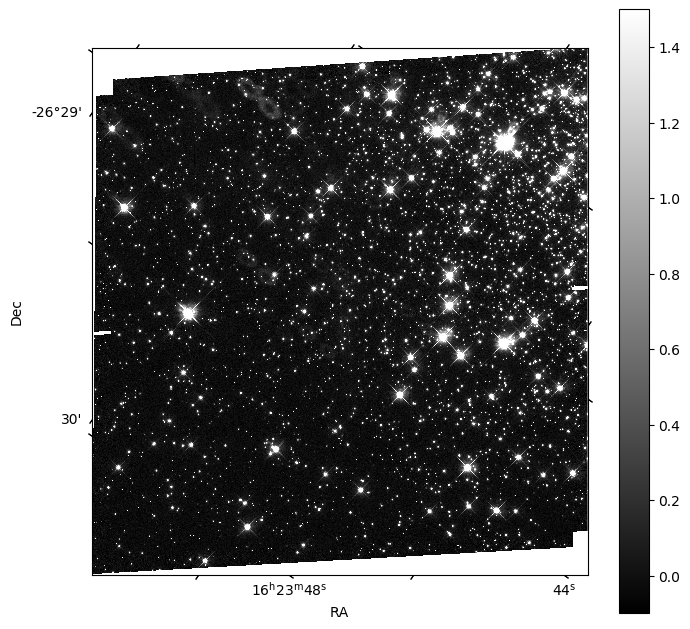

In [12]:
from astropy.visualization import (MinMaxInterval, SqrtStretch, ImageNormalize, ManualInterval)

# Create an ImageNormalize object
#norm = ImageNormalize(image_data, interval=MinMaxInterval(), stretch=SqrtStretch())
norm = ImageNormalize(image_data, interval = ManualInterval(-0.1,1.5))
print(wcs)

# Display the image
fig = plt.figure(figsize=(8,8),dpi=100)
ax = fig.add_subplot(111,projection=wcs)
im = ax.imshow(image_data, cmap='gray', origin='lower', norm=norm)
fig.colorbar(im)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")

### Step 4. Plot the HSC sources on the image. 

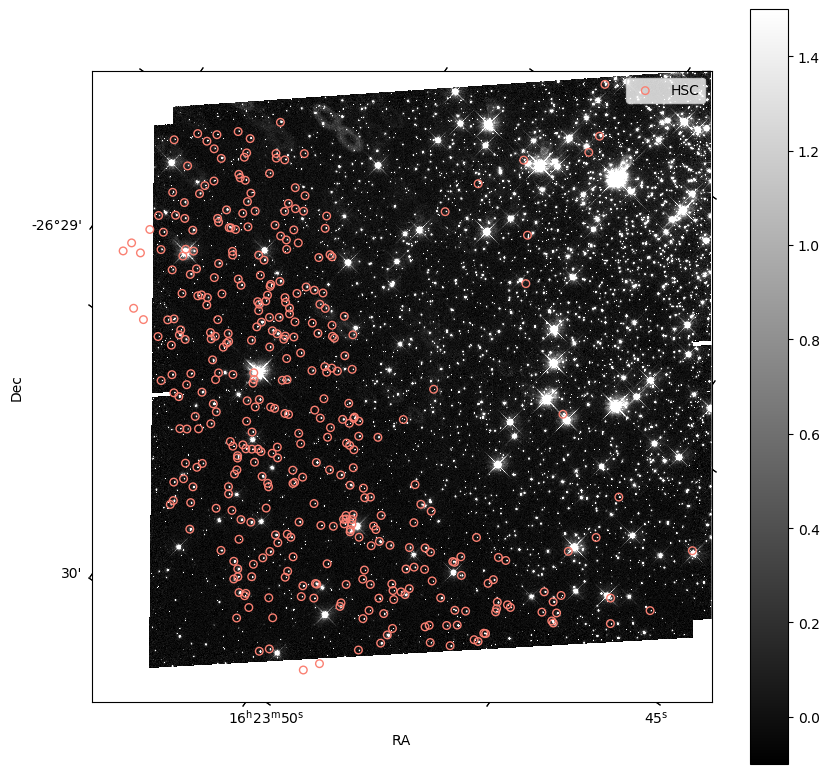

In [13]:
# Create an ImageNormalize object
norm = ImageNormalize(image_data, interval = ManualInterval(-0.1,1.5))

# Display the image and HSC 
fig = plt.figure(figsize=(10,10),dpi=100)
ax = fig.add_subplot(111,projection=wcs)
im = ax.imshow(image_data, cmap='gray', origin='lower', norm=norm)
p1 = ax.scatter(hsc['match_ra'],hsc['match_dec'],transform=ax.get_transform('world'), \
                s=30, edgecolor='salmon', facecolor='none', label='HSC')
fig.colorbar(im)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.legend(["HSC"])

### Step 5. Create a colour-magnitude diagram to help identify white dwarfs. 

The following plots a colour-magnitude diagram of F275W-F814W versus F275W. 

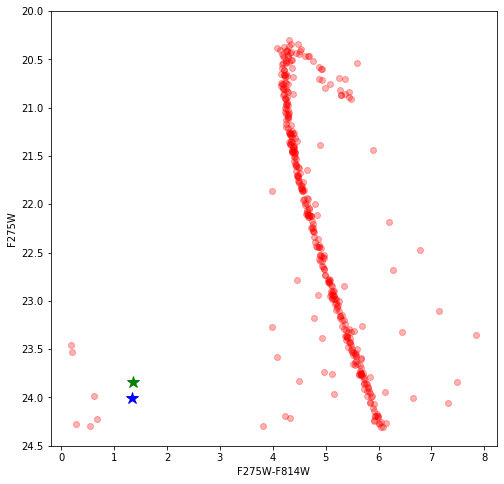

In [14]:
x = hsc['expr1']
y = hsc['w3_f275w']

plt.figure(figsize=(8, 8))
plt.scatter(hsc['expr1'], hsc['w3_f275w'], color='r', alpha=0.3)
plt.plot(x[2], y[2], 'g*', markersize=12)
plt.plot(x[353], y[353], 'b*', markersize=12)
plt.ylim(24.5, 20.0)  # flip the y axis
plt.xlabel('F275W-F814W')
plt.ylabel('F275W')
plt.show()

The white dwarfs are blueward of the main band of stars. Of the 8 objects in the WD area, 6 are in Richer et. al. 1997, 1 is not in the WFPC2 FOV (green) used by Richer and hence is a new white dwarf candidate, and 1 is not visible on the WFPC2 F814W image (but is in the WFC3 data so is in the HSC; blue). 

### Step 6.  Select the white dwarf candidates and plot these on the image.

Now we know where the white dwarfs lie (wf_f814w > 22.0 mag) we can again query the HSC for the 8 objects:

In [15]:
wd = esahubble.query_hst_tap("SELECT match_ra, match_dec, match_id, num_images, w3_f275w, w3_f814w, w3_f275w - w3_f814w \
FROM hsc_v2.hubble_sc2 \
WHERE 1=CONTAINS( \
  POINT('ICRS', match_ra, match_dec), \
  CIRCLE('ICRS', 245.89675, -26.52575, 0.138889)) \
AND ci < 1.25 \
AND num_images > 2 \
AND (w3_f275w > 0 and w3_f814w > 0) \
AND w3_f814w > 22.0 \
AND w3_f275w_sigma < 1.0 \
AND w3_f814w_sigma < 1.0 \
ORDER BY match_id ASC", "M4.vot")
wd

# Brings back a table of 8 rows. 

INFO: Query finished. [astroquery.utils.tap.core]


match_ra,match_dec,match_id,num_images,w3_f275w,w3_f814w,expr1
float64,float64,int64,int32,float64,float64,float64
245.8990812664547,-26.513830608407527,13383976,61,23.84429931640625,22.485200881958008,1.3590984344482422
245.9215342804477,-26.49831121320308,13423493,14,23.45439910888672,23.264349937438965,0.1900491714477539
245.9363966068562,-26.499198456953778,13434767,5,23.532550811767578,23.33155059814453,0.20100021362304688
245.94350136121454,-26.50880422747378,13448404,5,23.97985076904297,23.36669921875,0.6131515502929688
245.95202422502018,-26.51237468540509,13454851,5,24.272650718688965,24.001100540161133,0.27155017852783203
245.95153175320743,-26.514496811525326,13456113,5,24.219550132751465,23.55025005340576,0.6693000793457031
245.91247338058528,-26.515812890895322,13577547,125,24.00309944152832,22.659099578857422,1.3439998626708984
245.94106431605294,-26.500390791834747,13619127,4,24.29199981689453,23.753950119018555,0.5380496978759766


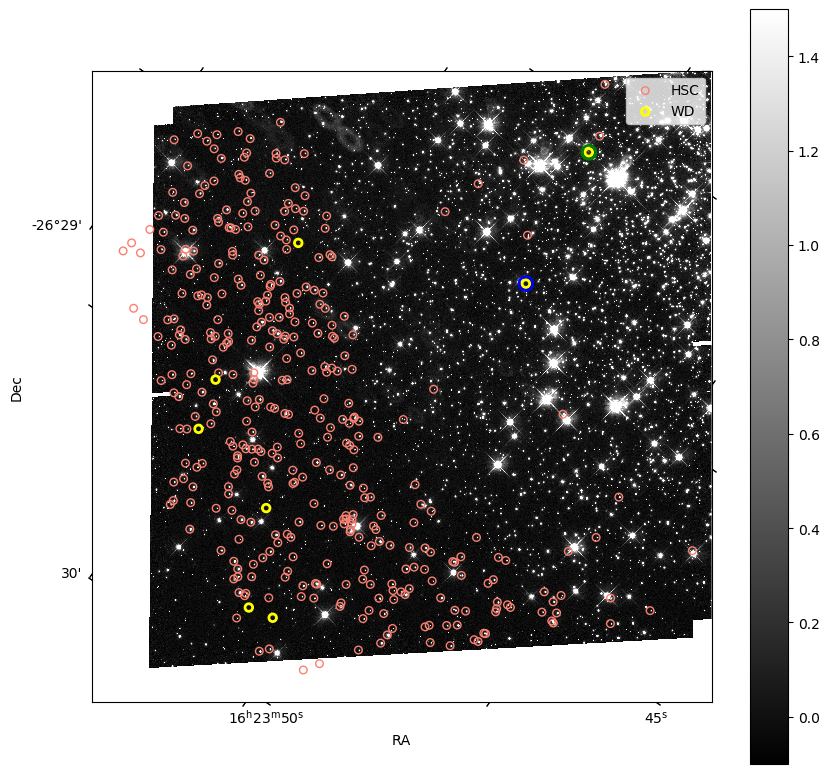

In [16]:
# Create an ImageNormalize object
norm = ImageNormalize(image_data, interval = ManualInterval(-0.1,1.5))

# Display the image and HSC 
fig = plt.figure(figsize=(10,10),dpi=100)
ax = fig.add_subplot(111,projection=wcs)
im = ax.imshow(image_data, cmap='gray', origin='lower', norm=norm)
p1 = ax.scatter(hsc['match_ra'],hsc['match_dec'],transform=ax.get_transform('world'), \
                s=30, edgecolor='salmon', facecolor='none', label='HSC')
p2 = ax.scatter(wd['match_ra'],wd['match_dec'],transform=ax.get_transform('world'), \
                s=30, edgecolor='yellow', facecolor='none', label='WD', linewidths=2)
p3 = ax.scatter(hsc['match_ra'][2],hsc['match_dec'][2],transform=ax.get_transform('world'), \
                s=100, edgecolor='green', facecolor='none', linewidths=2)
p4 = ax.scatter(hsc['match_ra'][353],hsc['match_dec'][353],transform=ax.get_transform('world'), \
                s=100, edgecolor='blue', facecolor='none', linewidths=2)
fig.colorbar(im)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.legend(["HSC", "WD"])